<a href="https://colab.research.google.com/github/JFavela1/IPYNB/blob/main/new_nbs_2025/dependency_parsing_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

From [the NLTK dependency page.](https://www.nltk.org/howto/dependency.html)

##  Getting examples of dependency analyses

Note: This notebook produces images of trees and graphs, but in ordre to see those images, you will in many cases need to re-execute the code cell.

In [2]:
import nltk
nltk.download("dependency_treebank")

[nltk_data] Downloading package dependency_treebank to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping corpora/dependency_treebank.zip.


True

In [3]:
from nltk.corpus import dependency_treebank
from nltk.grammar import DependencyGrammar
from nltk.parse import (
      DependencyGraph,
     ProjectiveDependencyParser,
     NonprojectiveDependencyParser,
)

wds = dependency_treebank.words()
ps = dependency_treebank.parsed_sents()
# One DependencyGraph isntance
dg = ps[0]
sent = wds[:18]

sent

['Pierre',
 'Vinken',
 ',',
 '61',
 'years',
 'old',
 ',',
 'will',
 'join',
 'the',
 'board',
 'as',
 'a',
 'nonexecutive',
 'director',
 'Nov.',
 '29',
 '.']

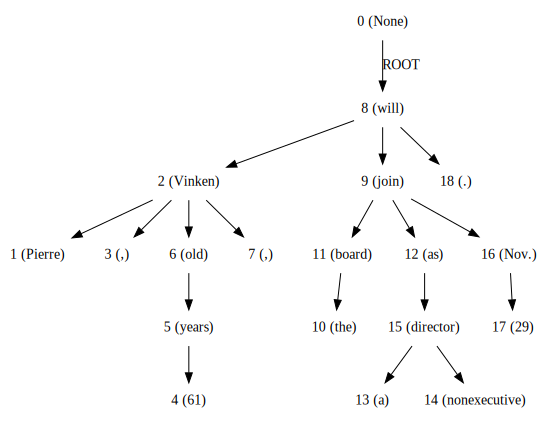

In [4]:
dg

A string representing a standard format (MALT) for representing dependency trees.

In [5]:
# Choose a format
dep_str = dg.to_conll(3)
print(dep_str)

Pierre	NNP	2
Vinken	NNP	8
,	,	2
61	CD	5
years	NNS	6
old	JJ	2
,	,	2
will	MD	0
join	VB	8
the	DT	11
board	NN	9
as	IN	9
a	DT	15
nonexecutive	JJ	15
director	NN	12
Nov.	NNP	9
29	CD	16
.	.	8



## Drawn as a tree

Words only, word order info implicit.

<class 'nltk.tree.tree.Tree'>
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 9.0 MB/s eta 0:00:00


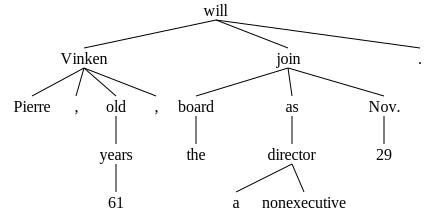

In [6]:
nltk_tree = dg.tree()
print(type(nltk_tree))
# Install svgling if not already installed
!pip install svgling
nltk_tree

A subclass of list; drts indexable by position(0-based)

In [7]:
t22 = nltk_tree[1][1][0][0]
t22

'a'

No info about whether the dependent  **29** occurred to the left or right of its parent **Nov** (Nov. 29,
vs 29 Nov.)

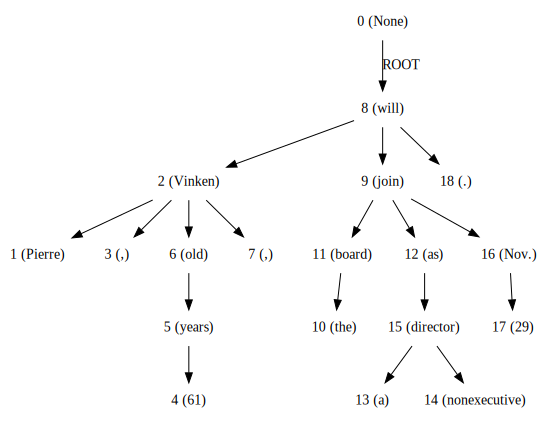

In [8]:
dg

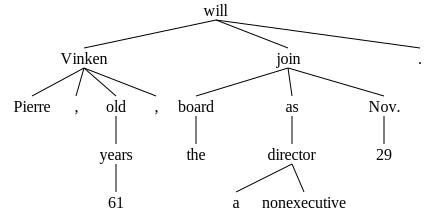

In [9]:
dg.tree()

Deoendents with index less than 8 occur to the left of parent; dependents with
index greater than 8 occur to the right.

In [10]:
print(len(dg.nodes))
dg.nodes[9]

19


{'address': 9,
 'word': 'join',
 'lemma': 'join',
 'ctag': 'VB',
 'tag': 'VB',
 'feats': '',
 'head': 8,
 'deps': defaultdict(list, {'': [11, 12, 16]}),
 'rel': ''}

In [11]:
dg.nodes[2]

{'address': 2,
 'word': 'Vinken',
 'lemma': 'Vinken',
 'ctag': 'NNP',
 'tag': 'NNP',
 'feats': '',
 'head': 8,
 'deps': defaultdict(list, {'': [1, 3, 6, 7]}),
 'rel': ''}

## Drawn as a graph

In [12]:
type(ps[0])

nltk.parse.dependencygraph.DependencyGraph

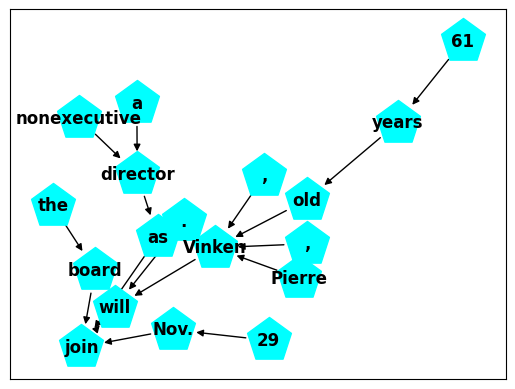

In [13]:
#ps = dependency_treebank.parsed_sents()

import networkx as nx
g0 =ps[0].nx_graph()
label_dict = ps[0].nx_labels
label_attr="label"
for (n,ndict) in g0.nodes(data=True):
    ndict[label_attr] = label_dict[n]

nx.draw_networkx(g0,labels = nx.get_node_attributes(g0,"label"),node_color="aqua",font_weight="bold",
                node_size=1_100,node_shape="p")

##   Drawing code for word graphs

There are already enough graph objects around to keep anyone happy (nltk.parse.dependencygraph.DependencyGraph, nltk.Tree, nx.DiGraph), so let's implement the idea of **word graph** entirely through images.

A word grph combines dependency information with information about the order of the words (like
the Depenedency Graph above) but highlights where in the word sequence a word find its
dependents/parent.

In [14]:
import subprocess
from string import punctuation
from IPython.display import Image
import os.path
import re

fn_bse = "/tmp/f00"

edge_sep_re = r"\s*\n\s*"
dependency_arrow_re = r"\s*->\s*"

def get_word_graph_img_from_word_edges (example,edges,fmt="png",nop=True):
    nop_str = get_word_graph_str_from_word_edges (example, edges)
    return get_image_from_nop_str (nop_str,fmt=fmt,nop=nop)

def get_word_graph_img_from_nx_graph (g0,penwidth=2.5,fmt="png",file_save_only=False,nop=True):
    """
    Create the nop2-appropriate dot file {fn_bse}.dot using
    the string generated from g0 by get_word_graph_str.

    Return the Ipyth image object from {fn_bse}.{fmt}
    """
    nop_str = get_word_graph_str_from_nx_graph(g0,penwidth=penwidth)
    return get_image_from_nop_str (nop_str,fn_bse, fmt,nop=nop)


def graph_template (nodes, edges,penwidth=2.5):
    return f"""
digraph G {{
      splines=true;
      edge [penwidth={penwidth}]
      subgraph {{
    {nodes}
    {edges}
      }}
    }}
    """


def node_template (name,pos,label=None,spacer=100):
    if label and len(label)>=8:
        spacer=130
    elif label and len(label)<3:
        space = 60
    pos += spacer
    if label is not None:
        return pos, f'  {name} [label="{label}", pos="{pos},0!"]'
    else:
        return pos, f'  {name} [pos="{pos},0!"]'

def edge_template (start,end,nodes):
    """
    Return dot edge declaration string if start and end have established positions
    in the word string.  Else None.

    This is used in filtering punctuation edges (for example, from Penn Treebank).
    """
    if start in nodes and end in nodes:
        return f"{start} -> {end}"


def make_indexing (example):
    """
    To do: real tokenizing.
    """
    example = example.split()
    idx_dict = {i:wd for (i,wd) in enumerate(example)}
    wd_dict = {wd:i for (i,wd) in idx_dict.items()}
    return idx_dict, wd_dict

def get_word_graph_str_from_word_edges(example, edges,penwidth=2.5):
    idx_dict, wd_dict = make_indexing (example)
    ## Make the nodes, repsecting word order in example str
    node_list = []
    nodes=[]
    pos=0
    for (idx,label) in idx_dict.items():
        if (isinstance(idx,str) and idx in punctuation) or (label and label in punctuation):
            continue
        pos, node_str = node_template (idx,pos,label=label)
        nodes.append(idx)
        node_list.append(node_str)
    return graph_template(
        nodes = "\n".join(node_list),
        # Make the edge_list from word edge string passed in.
        edges = "\n".join(parse_dependencies (edges,wd_dict,nodes)),
        penwidth=penwidth
    )

def parse_dependencies (edges,wd_dict,nodes,dot_fmt=True):
    edges = [elem for elem in  re.split(edge_sep_re, edges) if elem]
    edges = [tuple(wd_dict[wd] for wd in re.split(dependency_arrow_re, e)) for e in  edges]
    if dot_fmt:
        return [edge_template(start,end,nodes) for (start, end) in edges
                               if edge_template(start,end,nodes)]
    else:
        return edges

label_attr = "label"

def get_word_graph_str_from_nx_graph(g0,label_attr=label_attr,penwidth=2.5):
    """
    g0 is a networkx graph and the nodes iterable
    represents words in a phrase or sentence in their
    correct order.

    Render as a dot file string appropriate for
    the nop2  layout engine where every word is
    assigned a position.
    """
    node_list = []
    nodes = []
    pos = 0

    for (i,(nm,dd)) in enumerate(g0.nodes(data=True)):
        label = dd.get("label",None)
        if (isinstance(nm,str) and nm in punctuation) or (label and label in punctuation):
            continue
        pos, node_str = node_template (nm,pos,label=label)
        nodes.append(nm)
        node_list.append(node_str)
    try:
        # Allow for weighted eges
        edge_list = [edge_template(start,end,nodes) for (start, end, _wt) in g0.edges
                           if edge_template(start,end,nodes)]
    except ValueError:
        edge_list = [edge_template(start,end,nodes) for (start, end) in g0.edges
                           if edge_template(start,end,nodes)]
    return graph_template(
        nodes = "\n".join(node_list),
        edges = "\n".join(edge_list),
        penwidth=penwidth
    )


def get_image_from_nop_str (nop_str, fn_bse=fn_bse, fmt="png",file_save_only=False,
                           nop=True):
    """
    Write  nop_str to {fn_bse}.dot

    Run dot  -K nop2 on {fn_bse}.dot.

    Return the Ipython image object constructed
    from the bytes in the .png file generated by dot.

    The resulting Image object will display the image
    whenever its .`display() method is called, for
    example, when evaluated in a Jupter NB.
    """

    if fmt == "svg":
        file_save_only = True
    fn_bse = os.path.abspath(fn_bse)
    with open(f"{fn_bse}.dot","w") as ofh:
        ofh.write(nop_str)
    if nop:
        formatter = "-K nop2"
    else:
        formatter = ""
    subprocess.run([f"dot {formatter} -T {fmt} -o {fn_bse}.{fmt} {fn_bse}.dot"], shell=True)
    if file_save_only:
        if fmt == "svg":
            return f"file://{fn_bse}.svg"
        else:
            return f"{fn_base}.{fmt}"
    else:
        return read_img (f"{fn_bse}.{fmt}")
        #with open(f"{fn_bse}.{fmt}","rb") as fh:
        #    img = Image(fh.read())
        #return img

def read_img (fn):
    with open(fn,"rb") as fh:
        data = fh.read()
    return Image(data)

##  Drawn as a word graph

Remove the punctuation, preserve the order of the words, represent the same dependencies as in the graph.

Drawn as a word graph:

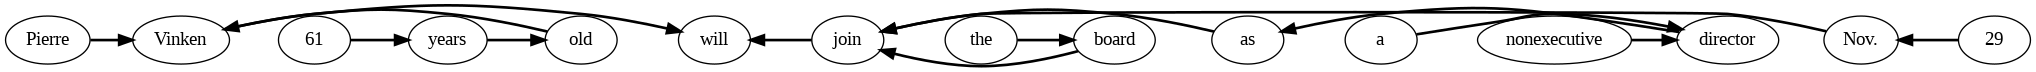

In [15]:
get_word_graph_img_from_nx_graph (g0,penwidth=2.0)

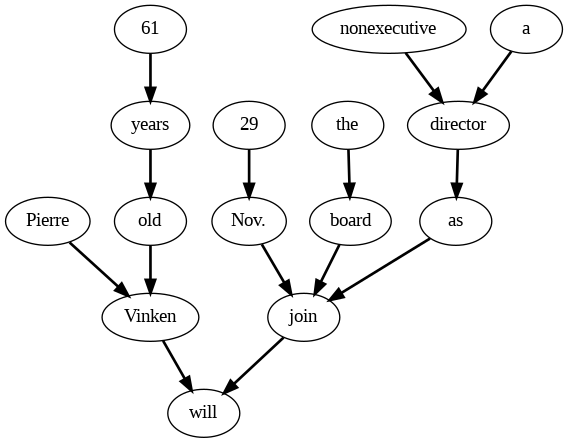

In [16]:
get_word_graph_img_from_nx_graph (g0,penwidth=2.0,nop=False)

## Dependency

**Definitions**

A word ${w}_{i}$ **depends_on** $w_{j}$ if and only if ${w}_{i}$ **modifies** $w_{j}$.  We will use the
terms as synonyms.  We will refer to $w_{i}$ as the dependent and $w_{j}$ as the parent.

The **depends_on${}^{*}$** relation is the transitive closure of the **depends_on** relation.

## Trees

Every tree is a graph.  But not every graph is a tree.  Some of the properties that define linguistic trees:

0.  There is a unique word, the ROOT, such that every word (except the ROOT itself)
    depends_on${}^{*}$ the ROOT. This
    distinguishes linguistic trees from the general class of what computer scientists call trees.
1.  Every node but one (the ROOT) has exactly one parent. That is, every word (except the ROOT) modifies
    something and a modifier can modify only one head.
2.  The graph is **acyclic**.  meaning there are no cycles of the form a -> b -> a or a -> b -> c -> a, etcetera.
    Thus, no word depends_on${}^{*}$ itself,


## Projectivity

A  word graph is projective if and only if whenever ${w}_{i}$ depends_on $w_{j}$,
each word $w_{k}$ that comes between $w_{i}$ and $w_{j}$ depends_on${}^{*}$ $w_{j}$.
If projectivity is violated, then some word $w_{k}$ that comes between $w_{i}$ and $w_{j}$
does not depend_on${}^{*}$ $w_{j}$.  In that case we call $w_{k}$ an **intervener**.

The overwhelming majority of English word graphs are projective. But --  there are exceptions.

First, an example of what projectivity means.

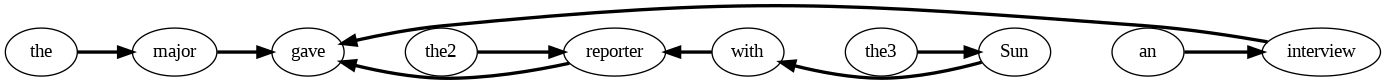

In [17]:
example = "the major gave the2 reporter with the3 Sun an interview"
edges = """
the -> major
major  -> gave
the2 -> reporter
reporter -> gave
with -> reporter
the3 -> Sun
Sun -> with
an -> interview
interview -> gave
"""
get_word_graph_img_from_word_edges (example,edges)

Consider *interview*, which depends on *gave*.  There are a lot of words in between *interview* and *gave*. You can verify that all them depend_on${}^{*}$ $gave$.  In fact there is a single word, *reporter*, that almost all those words  depend_on${}^{*}$ and *reporter* in turn depends on $gave$.

Because the graph is projective, it can be arranged into a tree with a fairly straightforward relationship
to the word. Every head word plus its dependents${}^{*}$ is a substring of the sentence.

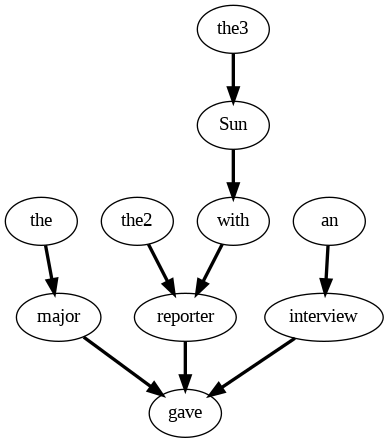

In [18]:
get_word_graph_img_from_word_edges (example,edges,nop=False)

# Non projective

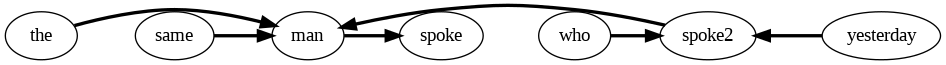

In [50]:
example = "the same man spoke who spoke2 yesterday"
edges = """
the -> man
same  -> man
man -> spoke
who -> spoke2
spoke2 -> man
yesterday -> spoke2
"""
get_word_graph_img_from_word_edges (example,edges)


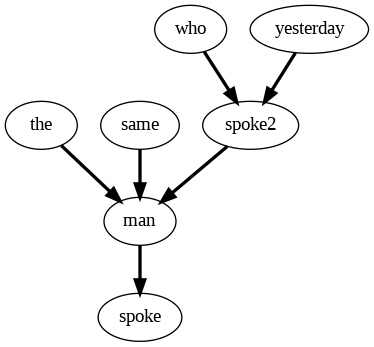

In [51]:
get_word_graph_img_from_word_edges (example,edges,nop=False)

The word labeled *spoke* is an intervener.  It lies between *man* ($w_{j}$) and  the second occurrence of *spoke*, labeled *spoke2* ($w_{i}$). Observe that *spoke* does not
depend_on${}^*$ *man*, as it should to satisfy Projectivity.  In fact, it's the root node of
of the graph so, instead  of *spoke* depending of *man*, *man* depends on *spoke*!

## Simpler examples

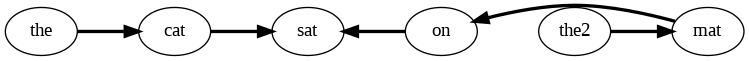

In [20]:
example = "the cat sat on the2 mat"

edges = """
the -> cat
cat -> sat
on -> sat
the2 -> mat
mat -> on
"""
get_word_graph_img_from_word_edges (example,edges)

For this example, the parts of speech have been attached.

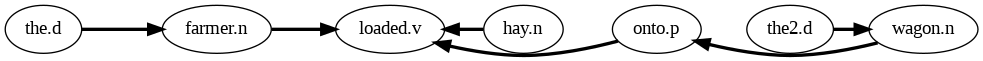

In [21]:
example = "the.d farmer.n loaded.v hay.n onto.p the2.d wagon.n"

edges = """
the.d -> farmer.n
farmer.n -> loaded.v
onto.p -> loaded.v
hay.n -> loaded.v
the2.d -> wagon.n
wagon.n -> onto.p
"""
get_word_graph_img_from_word_edges (example,edges)

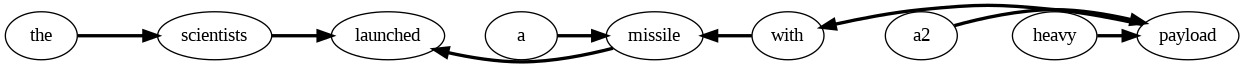

In [22]:
example = "the scientists launched a missile with a2 heavy payload"
edges = """
the -> scientists
scientists  -> launched
a -> missile
missile -> launched
with -> missile
a2 -> payload
heavy -> payload
payload -> with
"""
get_word_graph_img_from_word_edges (example,edges)

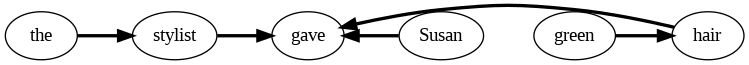

In [23]:
example = "the stylist gave Susan green hair"
edges = """
the -> stylist
stylist -> gave
Susan -> gave
green -> hair
hair -> gave
"""
get_word_graph_img_from_word_edges (example,edges)

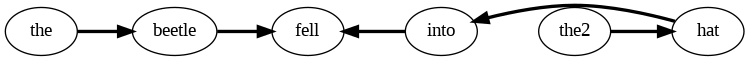

In [24]:
example = "the beetle fell into the2 hat"

edges = """
the -> beetle
beetle -> fell
into -> fell
the2 -> hat
hat -> into
"""
get_word_graph_img_from_word_edges (example,edges)

## Part One

Here are some **modification principles** stated as relations between parts of speech.  The modified
elements (the parents or **heads**) are always in boldface.

| Modifier | **Head** | Head Direction| Example
|:---:|:---:|:---:|:---|
| A | **N** | R | white **jersey** |
| A | **V** | L |  **is**  easy|
| D | **N** | R | the **dog**       |
| P | **N** | L | **book** about|
| P | **V** | L | **read** about  |
| N | **P** | L | about **Russia** |
| N | **V** | R | dogs **bark**  (Subject) |
|   |       | L | **saw** dogs  (Object)  |
| Adv | **V**| R | rarely **runs**  |
| Aux | **V**| R |  will **go**      |
| Aux | **A**| R |  is **happy**      |
| Inf | **to**| R |  to **please** |
| Neg | **not**| R | (is) not **happy**|
|     |        | R | (did) not **go** |


It's a long list, yes, but oberve that some possibilities are excluded.
Adjectives cannot modify prepositions; adverbs cannot modify nouns.
Use the possibilities that **are** listed as a guide in completing the exercise below.
Here are some words along with their parts of speech:


|Word| POS |
|:---|:---:|
| white | **A** |
| dented | **A** |
| happy | **A** |
| easy | **A** |
| red | **A** |
| a | **D** |
| her| **D** |
| his | **D** |
| the | **D** |
| their | **D** |
| about | **P** |
| across | **P** |
| down | **P** |
| for | **P** |
| in | **P** |
| into | **P** |
| on | **P** |
| onto | **P** |
| to | **P** |
| with | **P** |
| armband| **N** |
| astronomer | **N** |
| beetle | **N** |
| book | **N** |
| boy |  **N** |
| cat | **N**|
| child | **N**|
| farmer | **N** |
| gambler |  **N** |
| girl |  **N** |
| hammer |  **N** |
| hair |  **N** |
| hat |  **N** |
| hay |  **N** |
| house | **N** |
| interview | **N** |
| mat |  **N** |
| major | **N** |
| men | **N** |
| missile |  **N** |
| principles | **N** |
| reporter | **N** |
| scientists |  **N** |
| star |  **N** |
| stylist |  **N** |
| Susan |  **N** |
| table |  **N** |
| teacher |  **N** |
| telescope |  **N** |
| wagon |  **N** |
| winnings|  **N** |
| yard|  **N** |
| betray | **V** |
| fell | **V** |
| gave | **V** |
| launched | **V** |
| lay | **V** |
| pay | **V** |
| saw | **V**|
| often  | **Adv** |
| rarely  | **Adv** |
|  did |   **Aux**    |
| is   | **Auv** |
|  will |   **Aux** |
|  not |  **Neg** |
|  to  |  **Inf** |

Use this list as a guide in identifying the parts of speech and modification posibilities in the  exercises below.


Examine each word graph below and

1.  Identify the root

2.  Identify any graph that has any of the following properties.

>a.  It is not connected.

>b.  It has dependents with more than one parent.

>c.  It has cycles.

>d.  It has no root.

>e.  It is not projective.  

If you discover one or more of these properties in any example,
    state the property and for properties (a)-(d), propose an alternative graph that
    gives the correct description of the example sentence.   For property
    (e) identify an intervener that makes the graph non-projective.
    
3. There is at least one case in which the graph shows a preposition modifying the wrong head.
   Find it and correct.

If you want to correct a graph in any way, please leave the original analysis code cell as is.
Copy it and include a comment (Comment character is `#`) describing what your correction is.  Evaluate the copied cell to display your modified analysis.  In trying to correct a graph, you should consult the word list
above -- which has parts of speech (POSs) -- as well the modification principles.  Note that the
modification principles do not always lead to unambiguous results.  For example, a preposition
can modify either a V or or an N to its left, and sometimes both possibilities are
available in the same sentence. In such cases, which analysis is correct depends on the
meaning of the sentence.  Consider the prepositions in the
two sentences *The farmer loaded hay onto the wagon* and
*The scientists launched a missile with a heavy payload*, whose word graphs are given  above.

Note: To get a different, sometimes clearer, view of the links in the graph, you
can execute the cell that draws the word graph (to assign the desired values
to `example` and `edges`) and then redraw the graph as an ordinary graph  with the word order information
removed.  This has been done for you with the first example to illustrate.

#### Example 1:

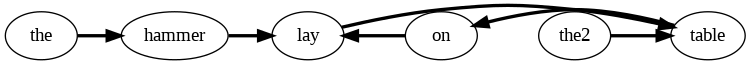

In [25]:
example = "the hammer lay on the2 table"

edges = """
the -> hammer
hammer -> lay
on  -> lay
the2  -> table
lay -> table
table -> on
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is lay
#This graph has a cycle with lay -> table -> on -> lay

A different view of the same graph:

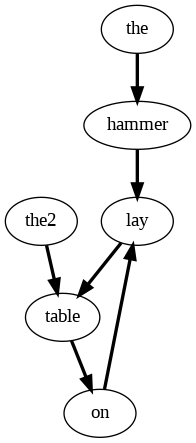

In [26]:
get_word_graph_img_from_word_edges (example,edges,nop=False)

#### Example 2:

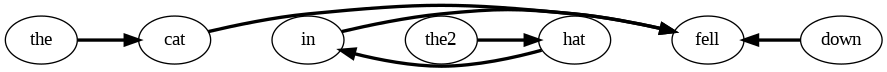

In [53]:
example = "the cat in the2 hat fell down"

edges = """
the -> cat
cat -> fell
in -> fell
the2 -> hat
hat -> in
down -> fell
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is fell


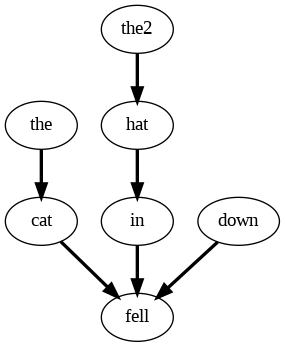

In [28]:
get_word_graph_img_from_word_edges (example,edges,nop=False)

#### Example 3:  

This one is somewhat unusual.  We simply note that all the edges are correct, but you should still
find the root and look for the unusual properties listed in (2a)-(2e) in the directions.

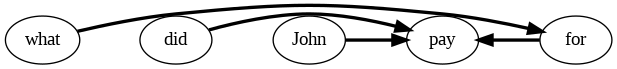

In [29]:
example = "what did John pay for"

edges = """
what -> for
did -> pay
John -> pay
for -> pay
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is pay

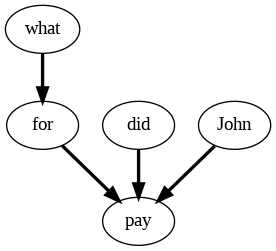

In [30]:
get_word_graph_img_from_word_edges (example,edges,nop=False)

#### Example 4:

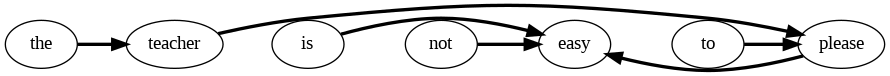

In [55]:
example = "the teacher is not easy to please"
#idx_dict, wd_dict = make_indexing (example)
edges = """
the -> teacher
teacher  -> please
not -> easy
is -> easy
to -> please
please -> easy
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is easy

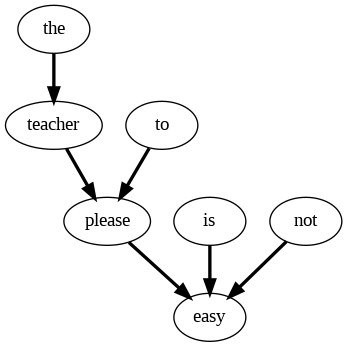

In [56]:
get_word_graph_img_from_word_edges (example,edges,nop=False)


#### Example 5:

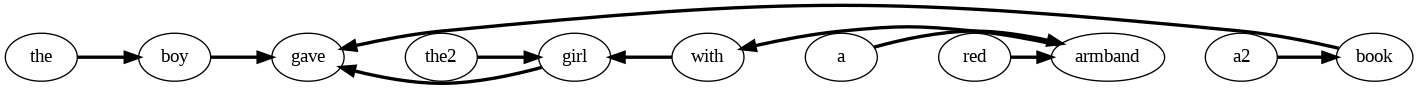

In [57]:
example = "the boy gave the2 girl with a red armband a2 book"
edges = """
the -> boy
boy  -> gave
the2 -> girl
girl -> gave
with -> girl
a -> armband
red -> armband
armband -> with
a2 -> book
book -> gave
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is gave

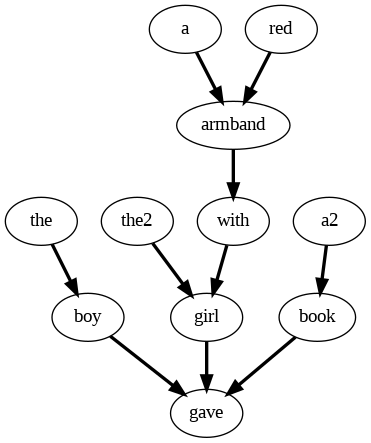

In [58]:
get_word_graph_img_from_word_edges (example,edges, nop=False)

#### Example 6:

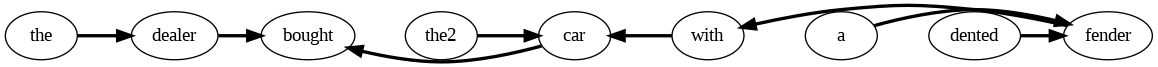

In [59]:
example = "the dealer bought the2 car with a dented fender"
edges = """
the -> dealer
dealer  -> bought
the2 -> car
car -> bought
with -> car
a -> fender
dented -> fender
fender -> with
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is bought

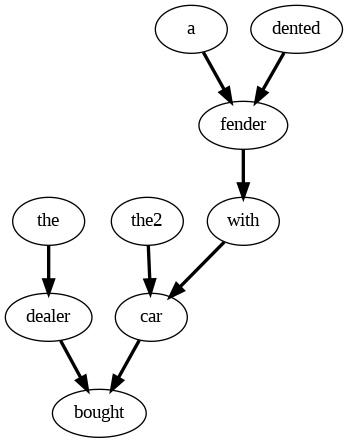

In [60]:
get_word_graph_img_from_word_edges (example,edges, nop=False)

#### Example 7:

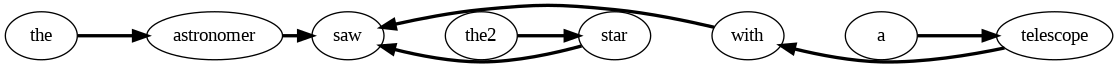

In [61]:
example = "the astronomer saw the2 star with a telescope"
edges = """
the -> astronomer
astronomer  -> saw
the2 -> star
star -> saw
with -> saw
a -> telescope
telescope -> with
"""
get_word_graph_img_from_word_edges (example,edges)

#The root is saw

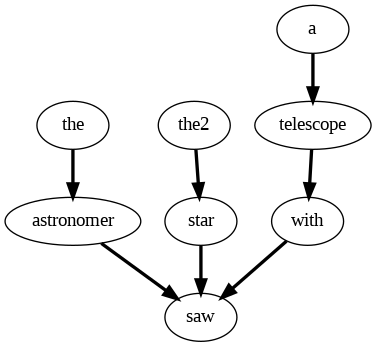

In [62]:
get_word_graph_img_from_word_edges (example,edges, nop=False)

## Part 2

Coding up your own word grapha.  

In each of the following cells, fill out the edge declarations
so as to specify a word graph for the example
sentence in the cell.  In some cases,
one or more edges have been declared for you.
To help you confirm that your analysis
is correct and complete,  you should execute
the cell and draw the word graph you've defined.


<div class="alert alert-block alert-info">
<b>Alert:</b> You
must end up with a connected graph with no cycles in which every word but one (the root)
depends on exactly one word.
</div>


The first cell which contains only a partial
analysis has been executed so as to show you
the result of an incomplete analysis: an unconnected graph.
The goal, then, is to produce a connected graph with a single root,
no child with multiple parents and a single root.  Oh yes, and try to
obey the modification principles.

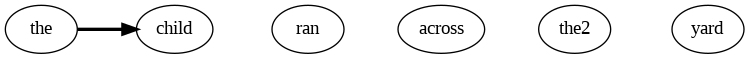

In [36]:
example = "the child ran across the2 yard"
edges = """
the -> child
"""
get_word_graph_img_from_word_edges (example,edges)

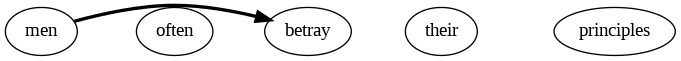

In [37]:
example = "men often betray their principles"
edges = """
men -> betray
"""
get_word_graph_img_from_word_edges (example,edges)

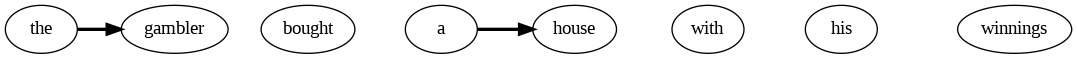

In [38]:
example = "the gambler bought a house with his winnings"
edges = """
a -> house
the -> gambler
"""
get_word_graph_img_from_word_edges (example,edges)

##  Appendix

##  Dependency edges to nx graph

Sketch of word graph interface to networkx: edges, order info -> nx graph preserving
order onfo in node sequence.

In [39]:
import networkx as nx

def make_nx_graph_edges_ordered_nodes (edges0, order_info, label_attr="label",weighted=False):
    """
    Both dependency link info (edges0) and word order info and are used
    to construct a networkx directed graph representing the word graph.

    The order info is encoded in the nodes iterable of the graph.
    """
    global seq
    g1 = nx.DiGraph()
    if isinstance(order_info,dict):
        # keys are word ordre indices, vals are words
        seq = sorted(list(order_info.keys()))
        #seq = [order_info[idx] for idx in seq]
        idx_dict = order_info
    else:
        seq = order_info
        idx_dict = order_info
    for n in seq:
        g1.add_node(n)
    if weighted:
        ## provide for possibility of edge weights
        edges=[]
        for e in edges0:
            try:
                (start,end,wt) = e
            except:
                (start,end) = e
                wt = None
            edges.append((start,end,wt))
        g1.add_weighted_edges_from(edges)
    else:
        g1.add_edges_from(edges0)
    for (idx,ndict) in g1.nodes(data=True):
        ndict[label_attr] = idx_dict[idx]
    return g1


def make_nx_word_graph_from_dependencies (example, edges):
    idx_dict, wd_dict = make_indexing (example)
    return make_nx_graph_edges_ordered_nodes (edges,idx_dict)

In [40]:

example = "the girl with the2 red armband"
idx_dict, wd_dict = make_indexing (example)


edges = """
the -> girl
with -> girl
the2 -> armband
red -> armband
armband -> with
"""

edges = parse_dependencies (edges,wd_dict,list(range(len(example.split()))),dot_fmt=False)
g1 = make_nx_word_graph_from_dependencies (example, edges)

Can be used like a normal graph:

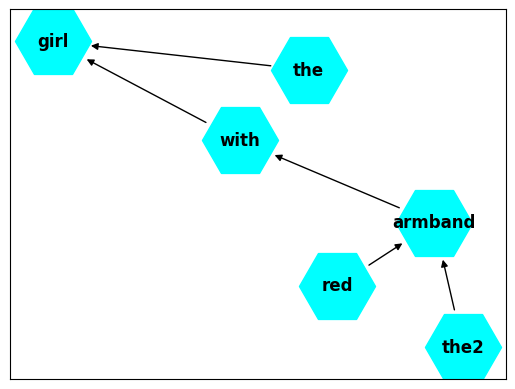

In [41]:
#labels = idx_dict,
nx.draw_networkx(g1,node_color="aqua",labels = idx_dict,font_weight="bold",node_size=3000,node_shape="H")

This rooted subgraph of the sentence graph for example 5 (Part One) is a **phrase**.

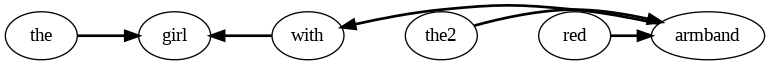

In [42]:
#get_word_graph_img (g1,fn_bse=fn_bse,penwidth=2.0)
get_word_graph_img_from_nx_graph (g1,penwidth=2.0)

##  Using the nltk dependency parser

In [43]:
grammar0 = DependencyGrammar.fromstring(
     """
    'fell' -> 'price' | 'stock'
    'price' -> 'of' | 'the'
    'of' -> 'stock'
    'stock' -> 'the'
    """
    )

In [44]:
pdp = ProjectiveDependencyParser(grammar0)
trees = pdp.parse(["the", "price", "of", "the", "stock", "fell"])
for tree in trees:
    print(tree)

(fell (price the of the) stock)
(fell (price the (of (stock the))))
(fell (price the of) (stock the))


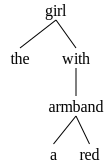

In [45]:
grammar22 = DependencyGrammar.fromstring(
        """
    'girl' -> 'the' | 'with'
    'armband' -> 'red' | 'a'
    'with' -> 'armband'
    'stock' -> 'the'
    """
    )

example = "the girl with a red armband"
pdp = ProjectiveDependencyParser(grammar22)
trees = pdp.parse(example.split())
for tree in trees:
    display(tree)

A parse is an NLTK Tree

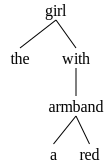

In [46]:
trees = pdp.parse(example.split())
tree= list(trees)[0]
tree

In [47]:
edges

[(0, 1), (2, 1), (3, 5), (4, 5), (5, 2)]

In [48]:
nx.get_node_attributes(g81,"pos")

NameError: name 'g81' is not defined

In [ ]:
import numpy as np

def tree_to_edges (nltk_tree):
    edges=[]
    tree_to_edges_helper (nltk_tree, edges)
    return edges

def tree_to_edges_helper (nltk_tree, edges):
    if hasattr(nltk_tree, "label"):
        label = nltk_tree.label()
        for t in nltk_tree:
            edges.append((label,tree_to_edges_helper(t, edges)))
        return label
    else:
        return nltk_tree


def make_nx_graph_from_nltk_tree (example, tree, y=10):
    """
    Expeirment with using pos att in drawing the tree
    """
    g81 = nx.DiGraph()
    pos_x = 0
    idx_dict = dict()
    for (i,wd) in enumerate(example.split()):
        y *= -1
        g81.add_node(i,pos=(pos_x,y),label=wd)
        pos_x += 70 + 10*(len(wd))
        idx_dict[i] = wd

    wd_dict = {wd:idx for (idx, wd) in idx_dict.items()}
    # [('girl', 'the'), ('armband', 'a'), ('armband', 'red'), ('with', 'armband'),('girl', 'with')]
    edges = tree_to_edges(tree)

    for (par, dep) in edges:
        g81.add_edge(wd_dict[dep],wd_dict[par])

    return g81,idx_dict


#  Uses pos_dict but resorts to stright line edges. Sigh.
#nx.draw_networkx(g81,node_color="aqua",labels = idx_dict,
#                 pos=nx.get_node_attributes(g81,"pos"),
#                 font_weight="bold")
import numpy as np
np.random.seed(50)
g81,idx_dict = make_nx_graph_from_nltk_tree (example, tree)
nx.draw_networkx(g81,node_color="aqua",labels = idx_dict,
                 pos=nx.get_node_attributes(g81,"pos"),
                 font_weight="bold",node_size=3_500)

In [ ]:
tree0

In [ ]:
example0

In [ ]:
tree0 = dg.tree()
example0 = ' '.join(sent)
np.random.seed(50)
g82,idx_dict = make_nx_graph_from_nltk_tree (example0, tree0)
nx.draw_networkx(g82,node_color="aqua",labels = idx_dict,
                 pos=nx.get_node_attributes(g82,"pos"),
                 font_weight="bold",node_size=1_000)

In [ ]:
#tree0
nltk_tree

In [ ]:
grammar = DependencyGrammar.fromstring(
        """
    'fell' -> 'price' | 'stock'
    'price' -> 'of' | 'the'
    'of' -> 'stock'
    'stock' -> 'the'
    """
    )

In [ ]:
print(grammar)

### Networkx builtin graphs

Projection of a dodecahedron (pentagonal faces) onto the plane.  All 20 vertices are visible.
The outermost (9,10,11,12,13) and the innermost pentagon  (2,3,4,5,6) are the least distorted pentagons.
These are the first and last shells in the `draw_shell` command.

The linked vertices are actual edges?

In [ ]:
G = nx.dodecahedral_graph()
shells = [[2, 3, 4, 5, 6], [8, 1, 0, 19, 18, 17, 16, 15, 14, 7], [9, 10, 11, 12, 13]]
nx.draw_shell(G, nlist=shells,with_labels=True,node_color="aqua")